#Дослідницький аналіз даних (EDA)

##1. Імпорт всіх необхідних бібліотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

In [ ]:
pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.4f}'.format)

warnings.filterwarnings('ignore')

##2. Опис структури даних

In [ ]:
#dataset = Path("../data/News_Category_Dataset.zip")
dataset = Path("/content/data/News_Category_Dataset.zip")

df = pd.read_json(dataset, lines=True, compression='zip')


Переглянемо перші п'ять записів наших даних:

In [ ]:
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


Кількість рядків та стовпців:

In [ ]:
df.shape

(209527, 6)

Типи даних та кількість пропусків:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.6+ MB


In [ ]:
null_count = df.isnull().sum()
null_percentage = round((df.isnull().sum()/df.shape[0])*100, 4)
null_df = pd.DataFrame({'column_name' : df.columns,'null_count' : null_count,'null_percentage': null_percentage})
null_df.reset_index(drop = True, inplace = True)

null_df.sort_values(by = 'null_percentage', ascending = False)

,column_name,null_count,null_percentage
0,link,0,0.0000
1,headline,0,0.0000
2,category,0,0.0000
3,short_description,0,0.0000
4,authors,0,0.0000
5,date,0,0.0000


***Спостереження:***

* У датасеті відсутні пропущені значення. Всі 209527 рядків містять заповнені значення для кожної з шести ознак.

In [ ]:
empty_strings = (
    df.astype(str)
      .apply(lambda col: col.str.strip().eq("").sum())
      .to_frame(name="empty_strings")
)

empty_strings

,empty_strings
link,0
headline,6
category,0
short_description,19712
authors,37418
date,0


In [ ]:
df[df["headline"].str.strip() == ""]

,link,headline,category,short_description,authors,date
90944,https://www.huffingtonpost.com/entry/lincoln-2...,,POLITICS,,"Robert Moran, ContributorRobert Moran leads Br...",2015-08-22
95567,https://www.huffingtonpost.com/entry/post_9671...,,RELIGION,Let everyone not wrapped in tired and disprove...,"Matthew Fox, ContributorRadical theologian Mat...",2015-06-30
103675,https://www.huffingtonpost.com/entry/us-and-eu...,,WORLDPOST,,"Natasha Srdoc, ContributorAuthor, Economist, C...",2015-03-29
109100,https://www.huffingtonpost.com/entry/disney-ce...,,BUSINESS,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-25
110153,https://www.huffingtonpost.com/entry/beverly-h...,,MEDIA,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-13
122145,https://www.huffingtonpost.com/entry/beverly-h...,,QUEER VOICES,,"Gary Snyder, ContributorWriter and Media Strat...",2014-08-28


***Спостереження:***
* Хоч формально незаповнених записів в датасеті немає,  однак додаткова перевірка виявила присутність полів, які заповнені порожніми текстовими рядками.

Знайдемо кількість дублікатів-рядків:

*   по всім полям


In [ ]:
df.duplicated().sum()

np.int64(13)

In [ ]:
df[df.duplicated()]

,link,headline,category,short_description,authors,date
67677,https://www.huffingtonpost.comhttp://www.mothe...,"On Facebook, Trump's Longtime Butler Calls For...",POLITICS,"Anthony Senecal, who worked as Donald Trump's ...",,2016-05-12
67923,https://www.huffingtonpost.comhttp://gizmodo.c...,Former Facebook Workers: We Routinely Suppress...,TECH,Facebook workers routinely suppressed news sto...,,2016-05-09
70239,https://www.huffingtonpost.comhttp://www.cnbc....,"On Equal Pay Day, The Gap Is Still Too Wide",WOMEN,Equal Pay Day falls on April 12 in 2016. It's ...,,2016-04-12
139830,https://www.huffingtonpost.comhttp://www.cnn.c...,The World's Most Dangerous Workout?,WELLNESS,"Is the ""sport of fitness"" the world's most dan...",,2014-02-10
144409,https://www.huffingtonpost.comhttp://www.upwor...,Some People Call It 'The Best Anti-Smoking Ad ...,WELLNESS,Almost all smokers know cigarettes are bad for...,,2013-12-22
145142,https://www.huffingtonpost.comhttp://www.weath...,10 Cities That Could Run Out Of Water - Weathe...,ENVIRONMENT,"Securing access to plentiful, renewable source...",,2013-12-15
178155,https://www.huffingtonpost.comhttp://www.busin...,Google Is Attacking Apple From The Inside Out ...,TECH,After years of hammering away at Apple's share...,,2013-01-01
187329,https://www.huffingtonpost.comhttp://www.nytim...,"Eating For Health, Not Weight",WELLNESS,Almost half of Americans are on a diet -- not ...,,2012-09-23
194596,https://www.huffingtonpost.comhttp://blogs.wsj...,Apple Removes Green EPEAT Electronics Certific...,TECH,Apple has pulled its products off the U.S. gov...,,2012-07-07
194598,https://www.huffingtonpost.comhttp://www.theda...,Microsoft's $6.2 Billion Writedown Shows It's ...,TECH,Fighting for online advertising dominance with...,,2012-07-07


***Спостереження:***
* Перевірка на дублікати показала наявність лише 13 повністю ідентичних записів. Така кількість є незначною і не впливає на загальну структуру датасету.

Перевіримо наявність дублікатів по ключовим полям, які ми будемо використовувати при навчанні моделей:

In [ ]:
duplicates_text = df.duplicated(subset=["headline", "short_description"]).sum()

print(f"Кількість: {duplicates_text}")
print(f"Частка: {duplicates_text / len(df) * 100:.4f}%")

Кількість: 489
Частка: 0.2334%


In [ ]:
duplicates = df[df.duplicated(subset=["headline", "short_description"], keep=False)]

duplicates.sort_values(["headline", "short_description"]).head(10)

,link,headline,category,short_description,authors,date
90944,https://www.huffingtonpost.com/entry/lincoln-2...,,POLITICS,,"Robert Moran, ContributorRobert Moran leads Br...",2015-08-22
103675,https://www.huffingtonpost.com/entry/us-and-eu...,,WORLDPOST,,"Natasha Srdoc, ContributorAuthor, Economist, C...",2015-03-29
109100,https://www.huffingtonpost.com/entry/disney-ce...,,BUSINESS,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-25
110153,https://www.huffingtonpost.com/entry/beverly-h...,,MEDIA,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-13
122145,https://www.huffingtonpost.com/entry/beverly-h...,,QUEER VOICES,,"Gary Snyder, ContributorWriter and Media Strat...",2014-08-28
205535,https://www.huffingtonpost.com/entry/black-lov...,'Black Love' Wedding Announcements (PHOTOS),BLACK VOICES,"""Black Love"" Wedding Announcements: Getting ma...",Julee Wilson,2012-03-11
206846,https://www.huffingtonpost.com/entry/black-lov...,'Black Love' Wedding Announcements (PHOTOS),BLACK VOICES,"""Black Love"" Wedding Announcements: Getting ma...",Julee Wilson,2012-02-26
208219,https://www.huffingtonpost.com/entry/black-lov...,'Black Love' Wedding Announcements (PHOTOS),BLACK VOICES,"""Black Love"" Wedding Announcements: Getting ma...",Julee Wilson,2012-02-11
208789,https://www.huffingtonpost.com/entry/black-lov...,'Black Love' Wedding Announcements (PHOTOS),BLACK VOICES,"""Black Love"" Wedding Announcements: Getting ma...",Julee Wilson,2012-02-05
205026,https://www.huffingtonpost.com/entry/riding-th...,'Riding The Dog': Coast-To-Coast By Greyhound Bus,TRAVEL,Why would you ride on Greyhound instead of dri...,"Peter Mandel, Contributor\nWashington Post con...",2012-03-16


In [ ]:
(
    df.groupby(["headline", "short_description"])["category"]
      .nunique()
      .value_counts()
)

,count
category,
1,209023
2,14
5,1


In [ ]:
problem_texts = (
    df.groupby(["headline", "short_description"])["category"]
      .nunique()
      .reset_index()
)

problem_texts = problem_texts[
    problem_texts["category"] > 1
]

problem_texts

,headline,short_description,category
0,,,5
18024,A Conversation With Decorator and Fashion Desi...,Much like the arresting color combinations she...,2
37982,Bring Back Our Girls,,2
48679,Could You Go a Year Without Buying Anything Ne...,There is one thing that sets me apart from the...,2
68222,Food for Thought,,2
91795,"Ikea Bag Dress Is Massive, In Need Of A Good S...",Corell's not the first person to turn the icon...,2
94879,Is Prostitution Just Another Job?,"Chelsea Lane was a freshman at Reed, the estee...",2
103353,"Kelly Rowland's Birthday: Singer Turns 31, Sty...",As one of the original members of Destiny's Ch...,2
112797,Marcia,,2
150016,She's Baaaaack!,,2


***Спостереження:***
* Аналіз повторюваних текстів показав, що переважна більшість унікальних комбінацій 'headline' та 'short_description' відповідає лише одній категорії. Лише 15 текстів мають неоднозначну розмітку. Така кількість є незначною і не впливає на загальну якість набору даних.

In [ ]:
df[df.duplicated()]["link"].head(10)

,link
67677,https://www.huffingtonpost.comhttp://www.mothe...
67923,https://www.huffingtonpost.comhttp://gizmodo.c...
70239,https://www.huffingtonpost.comhttp://www.cnbc....
139830,https://www.huffingtonpost.comhttp://www.cnn.c...
144409,https://www.huffingtonpost.comhttp://www.upwor...
145142,https://www.huffingtonpost.comhttp://www.weath...
178155,https://www.huffingtonpost.comhttp://www.busin...
187329,https://www.huffingtonpost.comhttp://www.nytim...
194596,https://www.huffingtonpost.comhttp://blogs.wsj...
194598,https://www.huffingtonpost.comhttp://www.theda...


***Спостереження:***
* Під час аналізу даних було виявлено, що частина значень у колонці 'link ' містить некоректно сформовані URL-адреси (об'єднання двох посилань в одному рядку). Оскільки ця ознака не планується використовувати для побудови моделі класифікації, виправлення цих значень не є доцільним.

###Аналіз цільової змінної

Оскільки сформульованою задачею цього проєкту є *"побудова моделі машинного навчання, яка визначає категорію звернення на основі його текстового опису для подальшого спрямування до відповідної команди підтримки"*, то в якості цільової змінної візьмемо дані колонки 'category'.

In [ ]:
target = "category"

Розглянемо унікальні значення цільової змінної:

In [ ]:
category_stats = (
    df["category"]
    .value_counts()
    .to_frame("count")
)

category_stats["percentage"] = (
    category_stats["count"] / len(df) * 100
).round(2)

category_stats

,count,percentage
category,,
POLITICS,35602,16.9900
WELLNESS,17945,8.5600
ENTERTAINMENT,17362,8.2900
TRAVEL,9900,4.7200
STYLE & BEAUTY,9814,4.6800
PARENTING,8791,4.2000
HEALTHY LIVING,6694,3.1900
QUEER VOICES,6347,3.0300
FOOD & DRINK,6340,3.0300


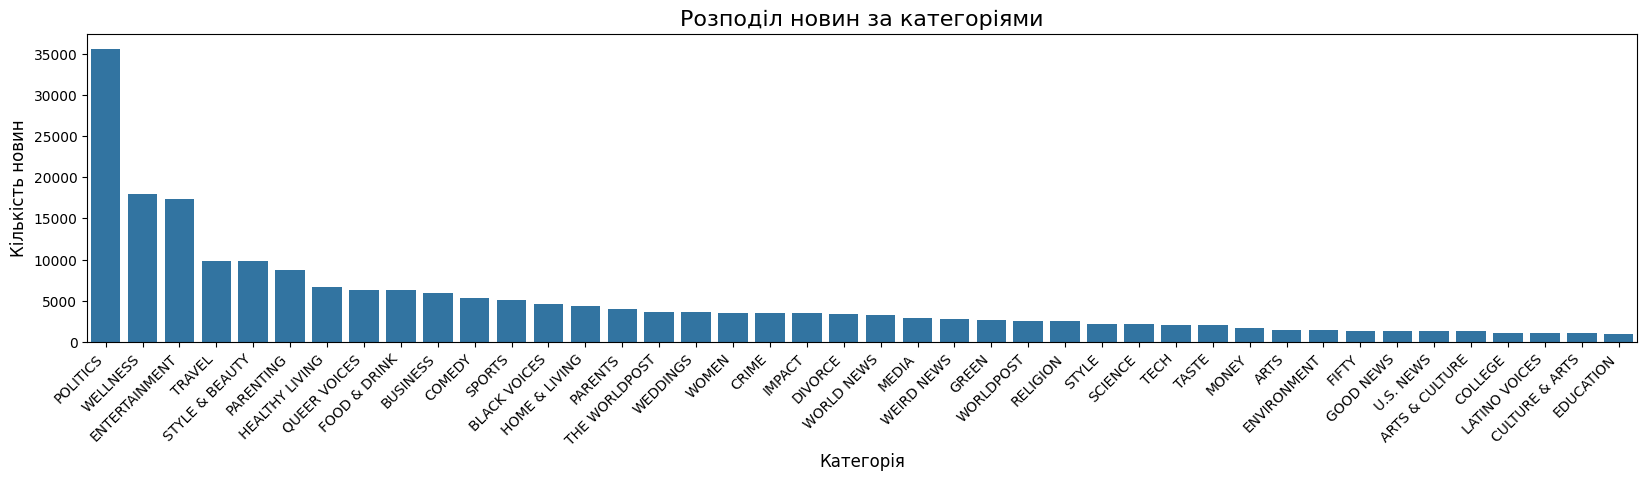

In [ ]:
plt.figure(figsize = (20,4))
sns.countplot(data = df, x = target, order=df[target].value_counts().index)
plt.title("Розподіл новин за категоріями", fontsize=16)
plt.xlabel("Категорія", fontsize=12)
plt.ylabel("Кількість новин", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.show()

***Спостереження:***

* Розподіл цільової змінної є незбалансованим. Найбільше записів належить до категорії POLITICS.
* Спостерігається значний дисбаланс між класами. Кількість новин у найбільшій категорії приблизно у 35 разів перевищує кількість новин у найменшій категорії. Це може негативно впливати на якість класифікації рідкісних категорій.


##3. Візуалізація ключових закономірностей та виявлення викидів

Розглянемо розподіл кількості новин за роками:

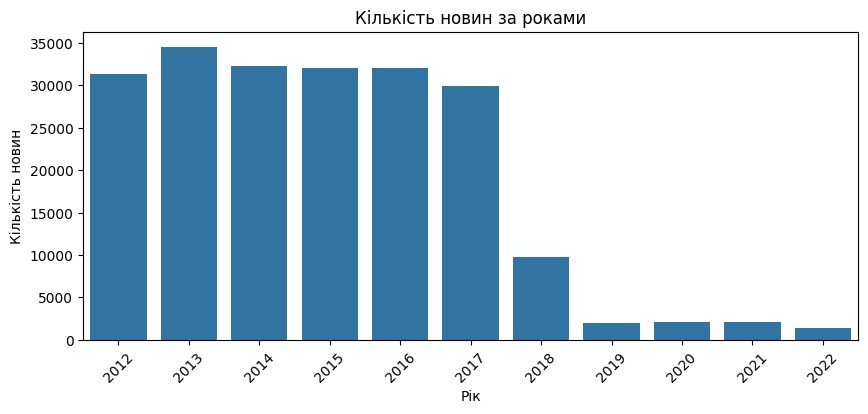

In [ ]:
news_per_year = df["date"].dt.year.value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.barplot(x=news_per_year.index, y=news_per_year.values)

plt.title("Кількість новин за роками")
plt.xlabel("Рік")
plt.ylabel("Кількість новин")
plt.xticks(rotation=45)
plt.show()

Проаналізуємо розподіл довжини тексту за ключовими полями для навчання моделей.



In [ ]:
df["text"] = (
    df["headline"] + " " + df["short_description"]
)

df["word_count"] = (
    df["text"]
      .str.split()
      .str.len()
)

In [ ]:
df["word_count"].quantile([0.25, 0.5, 0.75, 0.95, 0.99])

,word_count
0.2500,20.0000
0.5000,28.0000
0.7500,35.0000
0.9500,55.0000
0.9900,66.0000


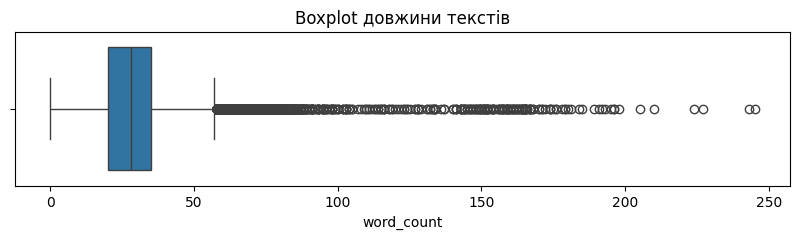

In [ ]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["word_count"]
)

plt.title("Boxplot довжини текстів")
plt.show()

***Спостереження:***
* Більшість текстів є короткими. Основна маса новин містить приблизно 20–40 слів, що відповідає формату заголовка та короткого опису.
* Спостерыгаэться велика кількість викидів. Графік показує багато спостережень, що перевищують верхню межу (приблизно 55 слів).Такі викиди не є помилками даних. Оскільки це, ймовірно, статті з більш розгорнутими описами або довшими заголовками. Видаляти ці викиди недоцільно, бо вони містять корисну інформацію і можуть позитивно впливати на якість побудов моделей.

Побудуємо розподіл середніх довжин тексту за категоріями:

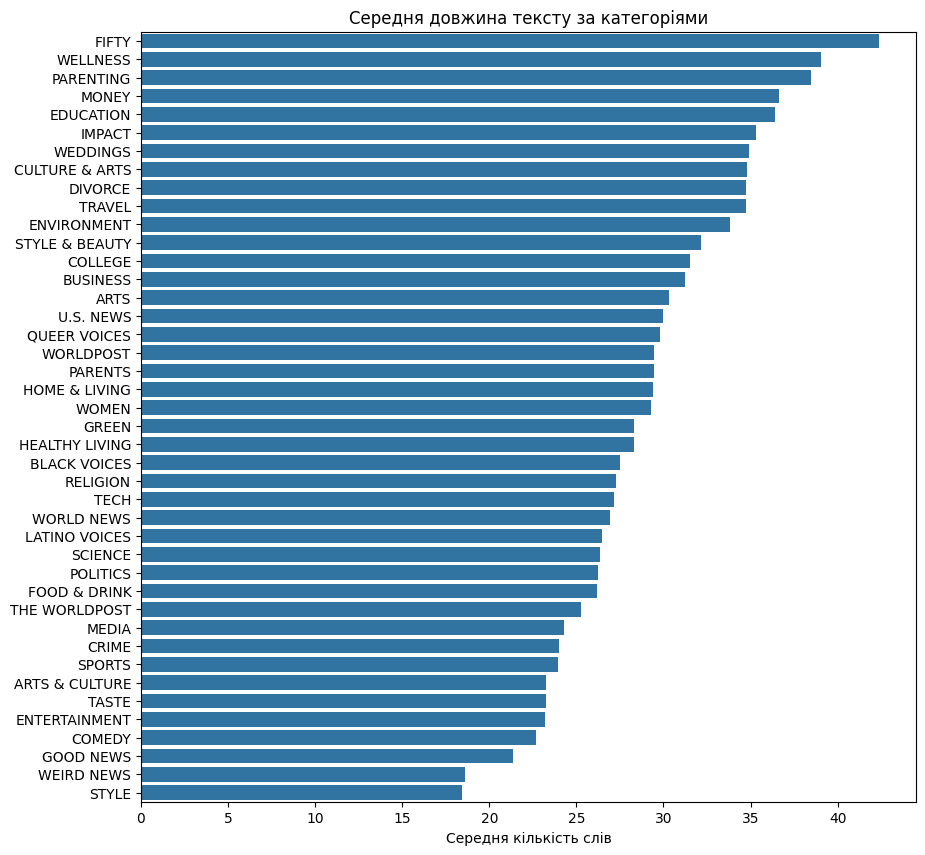

In [ ]:
category_length = (
    df.groupby("category")["word_count"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

sns.barplot(
    x=category_length.values,
    y=category_length.index
)

plt.title("Середня довжина тексту за категоріями")
plt.xlabel("Середня кількість слів")
plt.ylabel("")
plt.show()

Побудуємо теплову мапу розподілу категорій новин за роками:

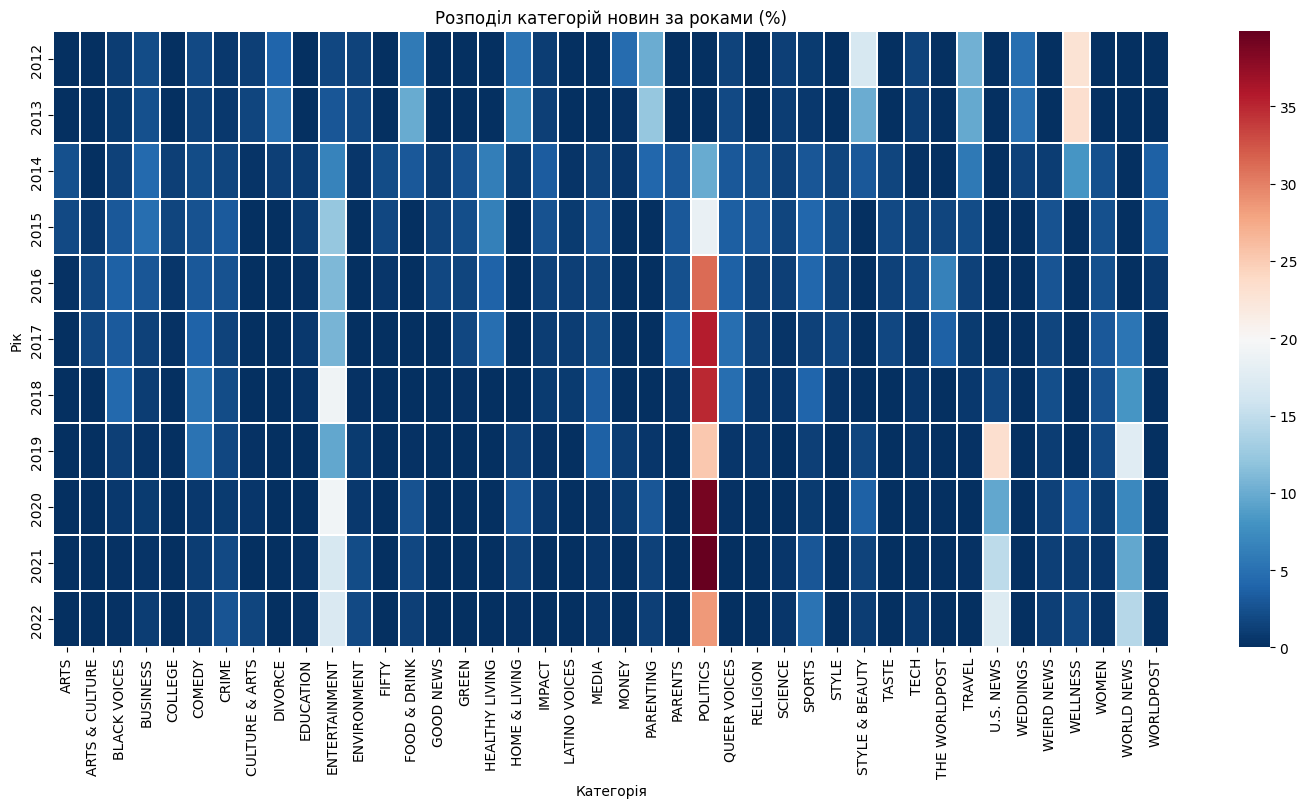

In [ ]:
category_year = pd.crosstab(
    df["date"].dt.year,
    df["category"],
    normalize="index"
) * 100

plt.figure(figsize=(18,8))

sns.heatmap(
    category_year,
    cmap="RdBu_r",
    linewidths=.3
)

plt.title("Розподіл категорій новин за роками (%)")
plt.xlabel("Категорія")
plt.ylabel("Рік")

plt.show()

***Спостереження:***
* Теплова мапа показує, що протягом більшості років найбільшу частку публікацій становили новини категорії POLITICS. особливо це стало помітно після 2015 року.
* Також можна спостерігати, що частка окремих категорій, зокрема ENTERTAINMENT, U.S. NEWS та WORLD NEWS, змінювалася від року до року, однак вони поступалися категорії POLITICS за кількістю публікацій.